# Network Intrusion Detection - Unified MLP Experiments

8개 네트워크 침입탐지 데이터셋(NSL-KDD, UNSW-NB15, CICIDS2017/2018, CIC-DDoS2019, Bot-IoT, TON_IoT, RT-IoT2022)에서 6종 손실함수(ce, pwce, lwce, plwce, cb, focal)를 비교한다.

- tabular/CIFAR 실험과 동일한 6 losses, Optuna 범위(PWCE 0.3-5.0, PLWCE 0.5-6.0, Focal 1.0-5.0), 5 seeds
- 데이터 로딩은 `network_data/scr/data_handler.py`의 `load_network_dataset(name)` 사용
- 데이터셋별로 load -> Optuna -> 학습 -> 저장 -> 메모리 해제 (대용량 대응)


In [1]:
# Cell 0: Setup
!pip install -q optuna openpyxl kagglehub

import os, sys, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import optuna
from optuna.samplers import GridSampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

REPO = '/content/drive/MyDrive/imbalanced-data-LWCE'
# custom_losses.py / experiment_utils.py 는 REPO 루트, data_handler.py 는 각 도메인 src/.
# insert(0)은 나중 호출이 앞에 오므로 REPO를 마지막에 넣어 우선순위를 준다.
sys.path.insert(0, f'{REPO}/network_data/src')
sys.path.insert(0, REPO)

from data_handler import load_network_dataset, DATASETS
from custom_losses import get_clf_loss
from experiment_utils import (GradLogger, extended_metrics, OPTUNA_GRIDS,
                              grid_n_trials, LOSS_CONFIGS_11, ABLATION_ROWS)

RESULTS_DIR = f'{REPO}/network_data/results/mlp'
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

# --- Constants (전 도메인 통일) ---
# 3차 피드백: §4.2 baseline에 logitadj 추가, §4.5 ablation에 combined 추가,
#             eslwce는 논문 proposed 3형제 중 하나라 필수.
LOSS_CONFIGS = LOSS_CONFIGS_11   # 11종: 기존 8 + eslwce/combined/logitadj
SEEDS        = [42, 43, 44, 45, 46]

BATCH_SIZE   = 512
FINAL_EPOCHS = 50
PROXY_EPOCHS = 10
PROXY_RATIO  = 0.20
# Optuna 그리드는 experiment_utils.OPTUNA_GRIDS로 통일 (1D 30 trials, combined만 2D 60).

print(f'Datasets: {DATASETS}')
print(f'Losses ({len(LOSS_CONFIGS)}): {LOSS_CONFIGS}')
print(f'Total: {len(DATASETS)} x {len(LOSS_CONFIGS)} x {len(SEEDS)} = '
      f'{len(DATASETS)*len(LOSS_CONFIGS)*len(SEEDS)} runs')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda | NVIDIA L4
Datasets: ['NSL-KDD', 'UNSW-NB15', 'CICIDS2017', 'CICIDS2018', 'CIC-DDoS2019', 'Bot-IoT', 'TON_IoT', 'RT-IoT2022']
Losses (11): ['ce', 'wce', 'pwce', 'sqce', 'lwce', 'plwce', 'eslwce', 'combined', 'cb', 'focal', 'logitadj']
Total: 8 x 11 x 5 = 440 runs


In [ ]:
# Cell 1: MLP model + metrics

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def compute_metrics(y_true, y_pred, class_counts):
    """
    3차 피드백 §4.3: Macro-F1, Balanced Acc, G-Mean, Minority Recall,
                    Worst-class Acc, Per-class Acc 를 모두 보고.
    기존 Head/Mid/Tail F1(F1 기반)은 그대로 유지하고, G-Mean/Worst-class는
    per-class recall 기반으로 별도 계산한다(표준 정의).
    """
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    f1m   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_pc = f1_score(y_true, y_pred, average=None,       zero_division=0).tolist()

    n   = len(class_counts)
    idx = np.argsort(class_counts)   # minority -> majority
    f1a = np.array(f1_pc)

    if n == 2:
        tail_f1, head_f1, mid_f1 = float(f1a[idx[0]]), float(f1a[idx[1]]), float(f1m)
    else:
        t       = max(1, n // 3)
        tail_f1 = float(f1a[idx[:t]].mean())
        mid_f1  = float(f1a[idx[t:2*t]].mean()) if 2 * t <= n else tail_f1
        head_f1 = float(f1a[idx[2*t:]].mean())  if 2 * t < n  else float(f1a[idx[-t:]].mean())

    out = dict(Accuracy=acc, Balanced_Accuracy=bacc, F1_Macro=f1m, F1_Weighted=f1w,
               Per_Class_F1=f1_pc, Head_F1=head_f1, Mid_F1=mid_f1, Tail_F1=tail_f1)
    # Per_Class_Acc(=recall) / G_Mean / Worst_Acc — 전 도메인 공용 정의
    out.update(extended_metrics(y_true, y_pred, n))
    return out


In [ ]:
# Cell 2: train_model (definition only)
# 3차 피드백 §4.7: epoch별 Gradient Norm / Minority·Majority Gradient Ratio 기록.
#   둘 다 학습이 끝나면 복구 불가능 → 반드시 루프 안에서 잡아야 한다.
#   network은 grad clipping을 쓰지 않으므로 GradLogger가 total_grad_norm()으로 측정
#   (clip_grad_norm_과 달리 grad를 수정하지 않아 학습 결과에 영향 없음).

def train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                loss_name, alpha=1.0, gamma=2.0, eps=0.1, tau=1.0, epochs=50, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tr_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
        batch_size=min(BATCH_SIZE, len(X_tr)), shuffle=True, num_workers=0)
    te_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te)),
        batch_size=4096, shuffle=False, num_workers=0)

    model     = MLP(X_tr.shape[1], num_classes).to(device)
    criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma,
                             eps=eps, tau=tau).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    glog = GradLogger(class_counts, num_classes, device)
    history = {'epoch': [], 'train_loss': [],
               'grad_norm': [], 'grad_many': [], 'grad_few': [], 'grad_ratio': []}

    for ep in range(epochs):
        model.train()
        glog.reset()
        run_loss, n_seen = 0.0, 0
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            logits.retain_grad()                 # 샘플별 로짓 기울기 관측 (Proposition 4)
            loss = criterion(logits, yb)
            loss.backward()
            glog.update(logits, yb, model)       # optimizer.step() 전에 호출
            optimizer.step()
            run_loss += float(loss) * yb.size(0); n_seen += yb.size(0)
        scheduler.step()

        history['epoch'].append(ep)
        history['train_loss'].append(run_loss / max(1, n_seen))
        for k, v in glog.epoch_end().items():
            history[k].append(v)

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in te_ld:
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    y_pred = np.concatenate(preds)

    metrics = compute_metrics(y_te, y_pred, class_counts)
    del model, criterion, optimizer
    gc.collect(); torch.cuda.empty_cache()
    return metrics, history


In [ ]:
# Cell 3: Optuna proxy helpers
# 3차 피드백 §3.3: proxy는 train의 stratified 부분집합, 선택 기준은 proxy-val F1-Macro.
#                 test set은 파라미터 선택에 일절 쓰지 않는다.
#            §4.6: study.trials 전체를 저장 → sensitivity 곡선을 추가 학습 없이 확보.

def proxy_score(X_ptr, y_ptr, X_pval, y_pval, class_counts, num_classes,
                loss_name, **params):
    torch.manual_seed(42)
    model = MLP(X_ptr.shape[1], num_classes).to(device)
    crit  = get_clf_loss(loss_name, class_counts, **params).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ld    = DataLoader(
        TensorDataset(torch.from_numpy(X_ptr), torch.from_numpy(y_ptr)),
        batch_size=min(BATCH_SIZE, len(X_ptr)), shuffle=True, num_workers=0)
    model.train()
    for _ in range(PROXY_EPOCHS):
        for xb, yb in ld:
            opt.zero_grad()
            crit(model(xb.to(device)), yb.to(device)).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X_pval).to(device)).argmax(1).cpu().numpy()
    score = f1_score(y_pval, preds, average='macro', zero_division=0)
    del model, crit, opt
    gc.collect(); torch.cuda.empty_cache()
    return score


def run_optuna(X_tr, y_tr, class_counts, num_classes, trials_store=None):
    """
    OPTUNA_GRIDS(전 도메인 통일)의 6개 study를 실행.
    Returns: {loss_name: {param: value}}  — 손실별 파라미터만 담은 flat dict
    """
    n_proxy = int(PROXY_RATIO * len(X_tr))
    try:
        proxy_idx, _ = train_test_split(np.arange(len(X_tr)), train_size=n_proxy,
                                        stratify=y_tr, random_state=42)
    except ValueError:
        proxy_idx = np.random.RandomState(42).choice(len(X_tr), n_proxy, replace=False)
    try:
        ptr_idx, pval_idx = train_test_split(proxy_idx, test_size=0.2,
                                             stratify=y_tr[proxy_idx], random_state=42)
    except ValueError:
        sp = int(0.8 * len(proxy_idx)); ptr_idx, pval_idx = proxy_idx[:sp], proxy_idx[sp:]
    X_ptr, y_ptr   = X_tr[ptr_idx],  y_tr[ptr_idx]
    X_pval, y_pval = X_tr[pval_idx], y_tr[pval_idx]

    bp = {}
    for loss_name, grid in OPTUNA_GRIDS.items():
        n_trials = grid_n_trials(grid)          # grid 크기와 정확히 일치해야 함

        def objective(trial, _ln=loss_name, _g=grid):
            params = {p: trial.suggest_float(p, min(vals), max(vals))
                      for p, vals in _g.items()}
            return proxy_score(X_ptr, y_ptr, X_pval, y_pval, class_counts,
                               num_classes, _ln, **params)

        st = optuna.create_study(direction='maximize', sampler=GridSampler(grid))
        st.optimize(objective, n_trials=n_trials)
        bp[loss_name] = dict(st.best_params)
        if trials_store is not None:
            # 'if t.value is not None' — 0.0 trial이 필터링되는 버그 방지
            trials_store[loss_name] = [{'params': t.params, 'value': t.value}
                                       for t in st.trials if t.value is not None]
        ps = ', '.join(f'{k}={v:.3f}' for k, v in st.best_params.items())
        print(f'  {loss_name:9s} {ps}  F1={st.best_value:.4f}')
    return bp


In [5]:
# Cell 4: Main loop — per dataset: load -> Optuna -> full train -> checkpoint -> free
os.environ['TQDM_DISABLE'] = '1'

# 11종 + gradient/per-class/history 포함. 옛 8종 결과와는 스키마가 다르므로
# Drive의 기존 결과 파일은 미리 정리(보관)한 뒤 실행할 것.
CKPT_PATH   = f'{RESULTS_DIR}/_checkpoint.json'
BP_PATH     = f'{RESULTS_DIR}/_best_params.json'
TRIALS_PATH = f'{RESULTS_DIR}/_optuna_trials.json'
HIST_PATH   = f'{RESULTS_DIR}/_histories.json'
COUNTS_PATH = f'{RESULTS_DIR}/_class_counts.json'   # 분석 셀에서 가중치 재계산용

all_results = []
best_params  = json.load(open(BP_PATH))     if os.path.exists(BP_PATH)     else {}
optuna_trials = json.load(open(TRIALS_PATH)) if os.path.exists(TRIALS_PATH) else {}
all_histories = json.load(open(HIST_PATH))   if os.path.exists(HIST_PATH)   else {}
all_counts    = json.load(open(COUNTS_PATH)) if os.path.exists(COUNTS_PATH) else {}
N_RUNS_PER_DS = len(LOSS_CONFIGS) * len(SEEDS)

for ds in DATASETS:
    ds_json = f'{RESULTS_DIR}/{ds}_results.json'
    # resume: 완료된 데이터셋은 건너뜀 (재다운로드/재학습 방지)
    if os.path.exists(ds_json):
        rows = json.load(open(ds_json))
        if len({(r['Loss'], r['Seed']) for r in rows}) == N_RUNS_PER_DS:
            all_results.extend(rows)
            print(f'[{ds}] done -- skip ({len(rows)} runs)')
            continue

    print(f'\n{"="*60}\n[{ds}] loading...')
    X_tr, X_te, y_tr, y_te, class_counts, num_classes, class_names = load_network_dataset(ds)

    if ds not in best_params:
        print(f'[{ds}] Optuna search...')
        ts = {}
        best_params[ds] = run_optuna(X_tr, y_tr, class_counts, num_classes, trials_store=ts)
        optuna_trials[ds] = ts
        json.dump(best_params, open(BP_PATH, 'w'), indent=2)
        json.dump(optuna_trials, open(TRIALS_PATH, 'w'), indent=2)
    bp = best_params[ds]

    ds_rows = json.load(open(ds_json)) if os.path.exists(ds_json) else []
    done = {(r['Loss'], r['Seed']) for r in ds_rows}
    all_histories.setdefault(ds, {})
    all_counts[ds] = list(map(int, class_counts))   # del 되기 전에 보존
    json.dump(all_counts, open(COUNTS_PATH, 'w'), indent=2)

    for loss in LOSS_CONFIGS:
        # bp[loss]는 해당 손실의 파라미터만 담고 있음. 없으면 기본값.
        # sqce는 파라미터가 없는 고정 손실(w ∝ 1/√n)이라 alpha를 넘기지 않는다.
        p = bp.get(loss, {})
        kw = dict(alpha=p.get('alpha', 1.0), gamma=p.get('gamma', 2.0),
                  eps=p.get('eps', 0.1), tau=p.get('tau', 1.0))

        new_run = False
        for seed in SEEDS:
            if (loss, seed) in done:
                continue
            m, hist = train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                                  loss_name=loss, epochs=FINAL_EPOCHS, seed=seed, **kw)
            ds_rows.append(dict(
                Dataset=ds, Loss=loss, Seed=seed,
                Accuracy=m['Accuracy'], Balanced_Accuracy=m['Balanced_Accuracy'],
                F1_Macro=m['F1_Macro'], F1_Weighted=m['F1_Weighted'],
                Head_F1=m['Head_F1'], Mid_F1=m['Mid_F1'], Tail_F1=m['Tail_F1'],
                # §4.3: 아래 4개가 v1에 없어서 G-Mean/Worst-class를 사후 계산할 수 없었다
                G_Mean=m['G_Mean'], Worst_Acc=m['Worst_Acc'],
                Per_Class_Acc=m['Per_Class_Acc'], Per_Class_F1=m['Per_Class_F1'],
                **kw))
            all_histories[ds][f'{loss}_s{seed}'] = hist
            new_run = True

        loss_f1 = [r['F1_Macro'] for r in ds_rows if r['Loss'] == loss]
        tail    = np.mean([r['Tail_F1'] for r in ds_rows if r['Loss'] == loss])
        gm      = np.mean([r.get('G_Mean', 0) for r in ds_rows if r['Loss'] == loss])
        print(f'  {loss:9s} F1={np.mean(loss_f1):.4f}+/-{np.std(loss_f1):.4f}  '
              f'Tail={tail:.4f}  G-Mean={gm:.4f}{"" if new_run else "  (cached)"}')
        if new_run:
            json.dump(ds_rows, open(ds_json, 'w'), indent=2)      # loss마다 저장
            json.dump(all_histories, open(HIST_PATH, 'w'))        # history는 용량 커서 indent 없음

    all_results.extend(ds_rows)
    json.dump(all_results, open(CKPT_PATH, 'w'), indent=2)
    del X_tr, X_te, y_tr, y_te
    gc.collect(); torch.cuda.empty_cache()

print('\nAll experiments complete.')

[NSL-KDD] done -- skip (55 runs)
[UNSW-NB15] done -- skip (55 runs)
[CICIDS2017] done -- skip (55 runs)
[CICIDS2018] done -- skip (55 runs)

[CIC-DDoS2019] loading...
Using Colab cache for faster access to the 'cicddos2019' dataset.
All files found (17):
  DNS-testing.parquet  (510,829 bytes)
  LDAP-testing.parquet  (224,356 bytes)
  LDAP-training.parquet  (619,804 bytes)
  MSSQL-testing.parquet  (421,867 bytes)
  MSSQL-training.parquet  (581,337 bytes)
  NTP-testing.parquet  (9,486,078 bytes)
  NetBIOS-testing.parquet  (253,946 bytes)
  NetBIOS-training.parquet  (223,235 bytes)
  Portmap-training.parquet  (570,907 bytes)
  SNMP-testing.parquet  (268,917 bytes)
  Syn-testing.parquet  (137,770 bytes)
  Syn-training.parquet  (8,608,068 bytes)
  TFTP-testing.parquet  (8,245,759 bytes)
  UDP-testing.parquet  (999,264 bytes)
  UDP-training.parquet  (1,384,962 bytes)
  UDPLag-testing.parquet  (1,269,445 bytes)
  UDPLag-training.parquet  (1,429,551 bytes)
Total rows: 431,371

✓ Loaded: Train=

100%|██████████| 1.17G/1.17G [01:08<00:00, 18.3MB/s]

Extracting files...


All files found (75):
  data_1.csv  (218,326,470 bytes)
  data_10.csv  (203,190,430 bytes)
  data_11.csv  (204,685,380 bytes)
  data_12.csv  (201,327,733 bytes)
  data_13.csv  (205,151,654 bytes)
  data_14.csv  (205,890,955 bytes)
  data_15.csv  (204,550,157 bytes)
  data_16.csv  (205,953,129 bytes)
  data_17.csv  (202,042,320 bytes)
  data_18.csv  (204,848,836 bytes)
  data_19.csv  (204,594,471 bytes)
  data_2.csv  (218,259,016 bytes)
  data_20.csv  (197,784,245 bytes)
  data_21.csv  (206,721,148 bytes)
  data_22.csv  (205,722,416 bytes)
  data_23.csv  (205,628,615 bytes)
  data_24.csv  (205,976,539 bytes)
  data_25.csv  (205,126,466 bytes)
  data_26.csv  (196,826,613 bytes)
  data_27.csv  (207,073,936 bytes)
  ... and 55 more
Loading 75 CSV files, up to 8,000 rows each...
Total rows loaded: 592,000

✓ Loaded: Train=140,053, Test=60,023, Input dim=17
Class distribution (train):
   0 DDoS                               :  73,791 (52.69%)
   1 DoS                                :  62,436

100%|██████████| 1.71M/1.71M [00:01<00:00, 1.39MB/s]

Extracting files...


Total rows: 211,043

✓ Loaded: Train=147,730, Test=63,313, Input dim=16
Class distribution (train):
   0 backdoor                           :  14,000 (9.48%)
   1 ddos                               :  14,000 (9.48%)
   2 dos                                :  14,000 (9.48%)
   3 injection                          :  14,000 (9.48%)
   4 mitm                               :     730 (0.49%)
   5 normal                             :  35,000 (23.69%)
   6 password                           :  14,000 (9.48%)
   7 ransomware                         :  14,000 (9.48%)
   8 scanning                           :  14,000 (9.48%)
   9 xss                                :  14,000 (9.48%)
Imbalance ratio: 48:1
[TON_IoT] Optuna search...
  pwce      alpha=1.272  F1=0.3803
  plwce     alpha=5.621  F1=0.3668
  focal     gamma=3.759  F1=0.2811
  eslwce    eps=0.672  F1=0.3534
  logitadj  tau=1.879  F1=0.3602
  combined  alpha=6.000, eps=0.100  F1=0.3867
  ce        F1=0.3098+/-0.1513  Tail=0.3146  G-Mean=0

100%|██████████| 3.64M/3.64M [00:01<00:00, 2.39MB/s]

Extracting files...


Total rows: 123,117

✓ Loaded: Train=86,181, Test=36,936, Input dim=82
Class distribution (train):
   0 ARP_poisioning                     :   5,425 (6.29%)
   1 DDOS_Slowloris                     :     374 (0.43%)
   2 DOS_SYN_Hping                      :  66,261 (76.89%)
   3 MQTT_Publish                       :   2,902 (3.37%)
   4 Metasploit_Brute_Force_SSH         :      26 (0.03%)
   5 NMAP_FIN_SCAN                      :      20 (0.02%)
   6 NMAP_OS_DETECTION                  :   1,400 (1.62%)
   7 NMAP_TCP_scan                      :     701 (0.81%)
   8 NMAP_UDP_SCAN                      :   1,813 (2.10%)
   9 NMAP_XMAS_TREE_SCAN                :   1,407 (1.63%)
  10 Thing_Speak                        :   5,675 (6.58%)
  11 Wipro_bulb                         :     177 (0.21%)
Imbalance ratio: 3313:1
[RT-IoT2022] Optuna search...
  pwce      alpha=0.624  F1=0.8873
  plwce     alpha=2.776  F1=0.9493
  focal     gamma=2.655  F1=0.7120
  eslwce    eps=0.788  F1=0.7178
  logitadj  

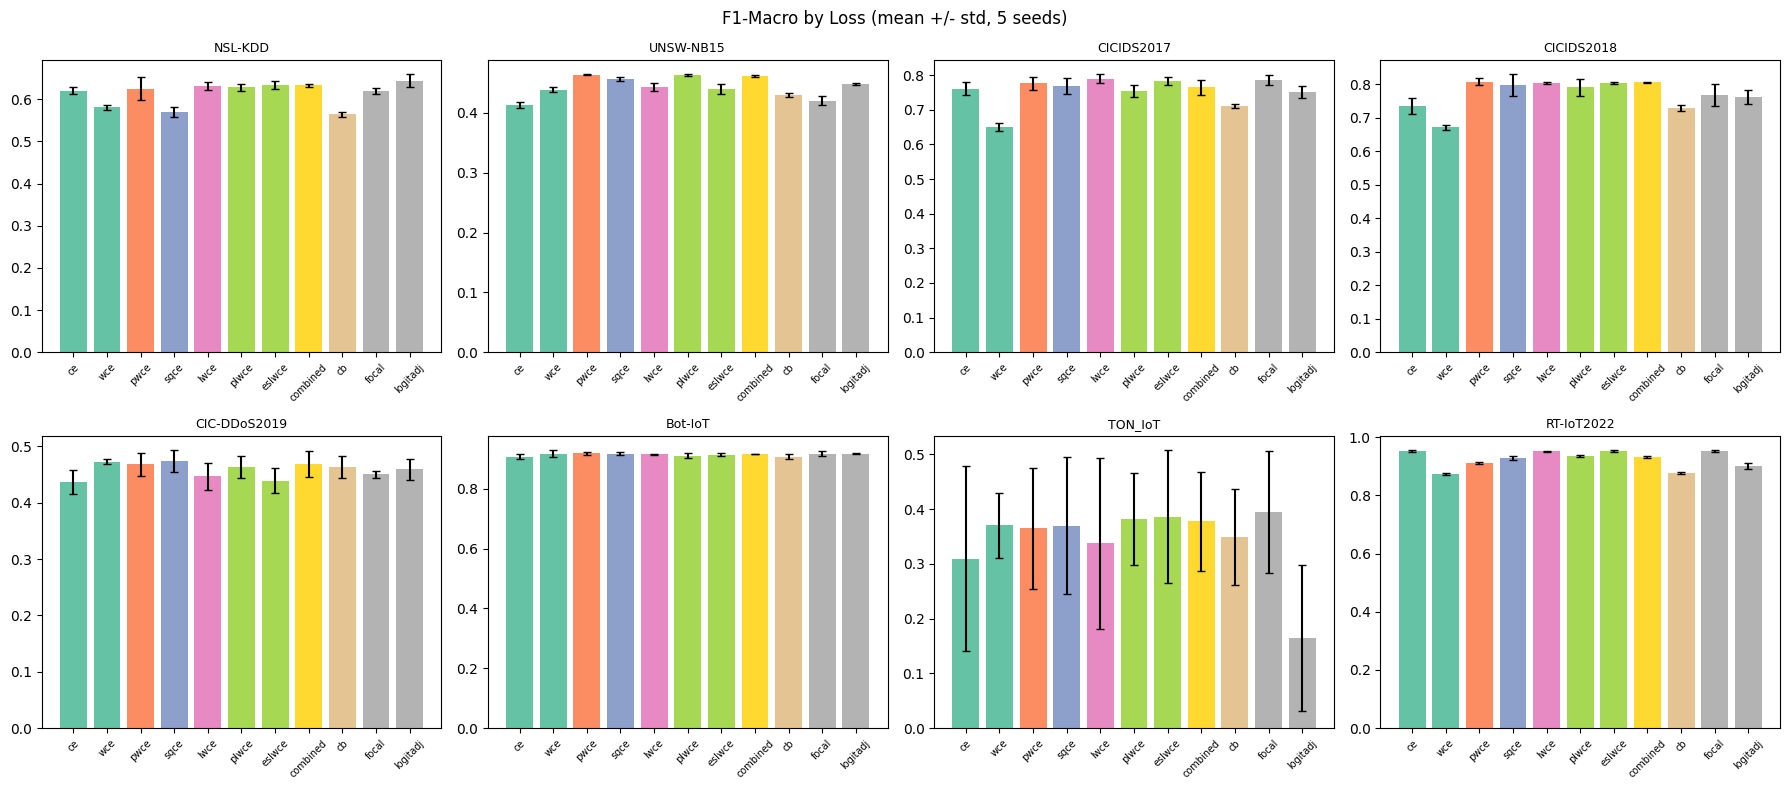

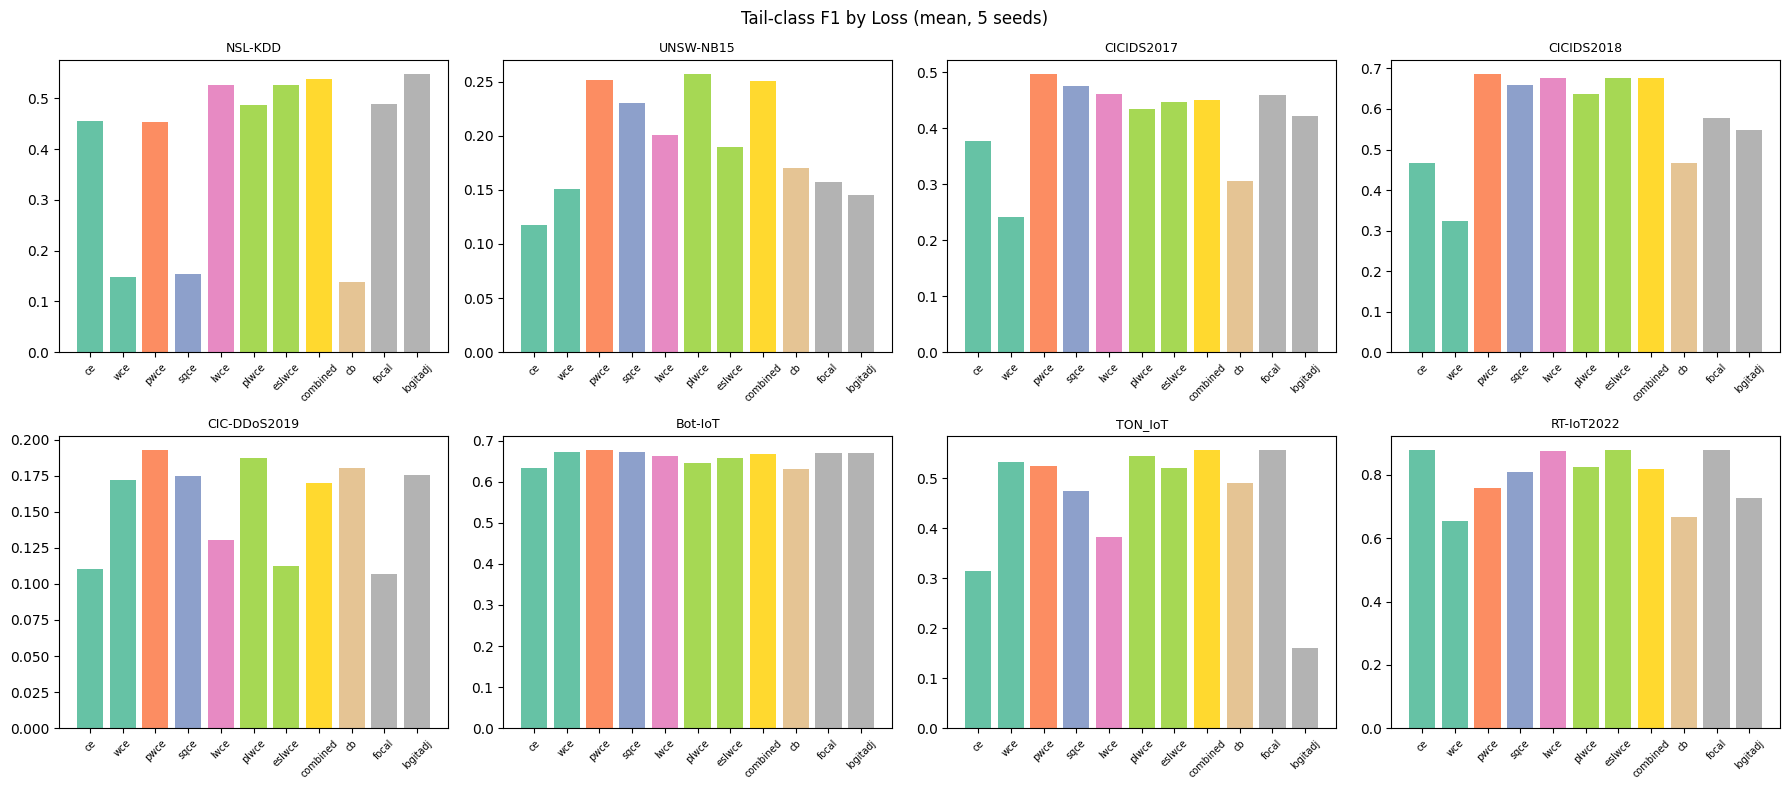

Loss             ce    wce   pwce   sqce   lwce  plwce  eslwce  combined     cb  focal  logitadj
Dataset                                                                                         
Bot-IoT      0.9073 0.9171 0.9182 0.9174 0.9147 0.9106  0.9132    0.9156 0.9065 0.9166    0.9165
CIC-DDoS2019 0.4367 0.4727 0.4680 0.4734 0.4471 0.4631  0.4393    0.4683 0.4631 0.4500    0.4590
CICIDS2017   0.7609 0.6499 0.7764 0.7683 0.7895 0.7544  0.7839    0.7645 0.7108 0.7852    0.7514
CICIDS2018   0.7352 0.6710 0.8082 0.7980 0.8044 0.7904  0.8042    0.8055 0.7287 0.7683    0.7615
NSL-KDD      0.6205 0.5805 0.6252 0.5701 0.6303 0.6279  0.6340    0.6336 0.5642 0.6196    0.6436
RT-IoT2022   0.9525 0.8734 0.9112 0.9287 0.9513 0.9343  0.9521    0.9313 0.8781 0.9518    0.9008
TON_IoT      0.3098 0.3705 0.3649 0.3699 0.3375 0.3820  0.3863    0.3780 0.3494 0.3955    0.1651
UNSW-NB15    0.4123 0.4387 0.4633 0.4573 0.4440 0.4633  0.4403    0.4614 0.4302 0.4202    0.4481

Saved: /content/drive/MyDrive

In [6]:
# Cell 5: Aggregate + visualization + save
results_df = pd.DataFrame(all_results)

agg = results_df.groupby(['Dataset', 'Loss']).agg(
    F1_Macro_mean     =('F1_Macro',          'mean'),
    F1_Macro_std      =('F1_Macro',          'std'),
    Balanced_Acc_mean =('Balanced_Accuracy', 'mean'),
    Tail_F1_mean      =('Tail_F1',           'mean'),
    Head_F1_mean      =('Head_F1',           'mean'),
    F1_Weighted_mean  =('F1_Weighted',       'mean'),
).reset_index()

colors  = plt.cm.Set2(np.linspace(0, 1, len(LOSS_CONFIGS)))
ds_list = [d for d in DATASETS if d in set(results_df['Dataset'])]

def grid_plot(value_col, title, fname):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    for idx, ds in enumerate(ds_list):
        ax  = axes[idx]
        sub = agg[agg['Dataset'] == ds].set_index('Loss')
        means = [sub.loc[l, value_col] if l in sub.index else 0 for l in LOSS_CONFIGS]
        stds  = ([sub.loc[l, 'F1_Macro_std'] if l in sub.index else 0 for l in LOSS_CONFIGS]
                 if value_col == 'F1_Macro_mean' else None)
        ax.bar(LOSS_CONFIGS, means, yerr=stds, color=colors, capsize=3)
        ax.set_title(ds, fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
    for i in range(len(ds_list), len(axes)):
        axes[i].set_visible(False)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/{fname}', dpi=120, bbox_inches='tight')
    plt.show()

grid_plot('F1_Macro_mean', 'F1-Macro by Loss (mean +/- std, 5 seeds)', 'f1_macro_comparison.png')
grid_plot('Tail_F1_mean',  'Tail-class F1 by Loss (mean, 5 seeds)',    'tail_f1_comparison.png')

pivot = agg.pivot_table(index='Dataset', columns='Loss', values='F1_Macro_mean')
print(pivot[LOSS_CONFIGS].to_string(float_format='{:.4f}'.format))

excel_path = f'{RESULTS_DIR}/network_mlp_results.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    agg.to_excel(writer, sheet_name='Summary', index=False)
    results_df.to_excel(writer, sheet_name='All_Runs', index=False)
    if best_params:
        pd.DataFrame(best_params).T.to_excel(writer, sheet_name='Best_Params')

json.dump(all_results, open(f'{RESULTS_DIR}/network_mlp_all_results.json', 'w'), indent=2)
print(f'\nSaved: {excel_path}')
print(f'Saved: {RESULTS_DIR}/network_mlp_all_results.json')


In [7]:
# === Cell 6: 3차 피드백 §4.5~4.7 분석 (mechanism / sensitivity / ablation) ===
# 통계검정(Friedman/Holm)은 '데이터셋을 블록'으로 두는 것이 정석이므로
# 전 도메인 결과가 모인 뒤 통합 스크립트에서 수행한다 (여기서는 생략).
from itertools import cycle

ANALYSIS_DIR = f'{RESULTS_DIR}/analysis'
os.makedirs(ANALYSIS_DIR, exist_ok=True)
colors_loss = plt.cm.tab20(np.linspace(0, 1, len(LOSS_CONFIGS)))

# class_counts는 학습 루프에서 저장해 둔 것을 읽는다.
# (network은 메모리 절약차 데이터셋마다 del 하므로 메모리에 남아있지 않음)
with open(COUNTS_PATH) as f:
    raw_counts = json.load(f)
ds_list = [d for d in DATASETS if d in all_histories and d in raw_counts]

# ── (1) §4.7 Optimization Stability — 데이터셋별 Gradient Norm & Few/Many Ratio ──
# "성능 향상만으로는 Weight Explosion 완화를 증명 못 한다"는 지적에 대한 직접 증거.
for key, ylab, logy in [('grad_norm', 'Gradient Norm (log)', True),
                        ('grad_ratio', 'Few/Many Gradient Ratio (log)', True),
                        ('train_loss', 'Train Loss', False)]:
    ncol = 4
    nrow = int(np.ceil(len(ds_list) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.4 * nrow))
    axes = np.atleast_1d(axes).flatten()
    for i, ds in enumerate(ds_list):
        ax = axes[i]
        for l_idx, loss_name in enumerate(LOSS_CONFIGS):
            hs = [all_histories[ds][f'{loss_name}_s{s}'] for s in SEEDS
                  if f'{loss_name}_s{s}' in all_histories[ds]]
            if not hs or key not in hs[0]:
                continue
            arr = np.array([h[key] for h in hs], dtype=float)
            mean = np.nanmean(arr, 0)
            ax.plot(np.arange(len(mean)), mean, label=loss_name,
                    color=colors_loss[l_idx], alpha=0.85, linewidth=1.1)
        if logy:
            ax.set_yscale('log')
        if key == 'grad_ratio':
            ax.axhline(1.0, color='k', linestyle=':', linewidth=1, alpha=0.6)
        ax.set_title(ds, fontsize=8); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    for j in range(len(ds_list), len(axes)):
        axes[j].set_visible(False)
    axes[0].set_ylabel(ylab); axes[0].legend(fontsize=6, ncol=2)
    plt.suptitle(ylab, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/stability_{key}.png', dpi=130, bbox_inches='tight')
    plt.close()

print('■ Gradient 통계 (마지막 epoch, seed 평균)')
print(f'{"Dataset":22s} | {"Loss":10s} | {"grad_norm":>10} | {"Few/Many":>9}')
print('-' * 60)
grad_summary = {}
for ds in ds_list:
    for loss_name in LOSS_CONFIGS:
        hs = [all_histories[ds][f'{loss_name}_s{s}'] for s in SEEDS
              if f'{loss_name}_s{s}' in all_histories[ds]]
        if not hs or 'grad_norm' not in hs[0]:
            continue
        gn = float(np.mean([h['grad_norm'][-1] for h in hs]))
        gr = float(np.nanmean([h['grad_ratio'][-1] for h in hs]))
        grad_summary[f'{ds}_{loss_name}'] = {'grad_norm_final': gn, 'grad_ratio_final': gr}
        print(f'{ds:22s} | {loss_name:10s} | {gn:10.4f} | {gr:9.3f}')

# ── (2) §4.7 Class Weight Distribution + Proposition 3 검증 ──
print('\n■ 가중치 동적 범위 w_rare/w_freq — Proposition 3')
print(f'{"Dataset":22s} | {"IR":>8} | {"Loss":10s} | {"w_rare/w_freq":>14} | 이론')
print('-' * 78)
THEORY = {'wce': 'rho', 'pwce': 'rho^alpha', 'sqce': 'sqrt(rho)',
          'lwce': 'O(log rho)', 'plwce': 'O((log rho)^alpha)',
          'eslwce': '<= LWCE', 'combined': 'O((log rho)^alpha)', 'cb': '-'}
ncol = 4
nrow = int(np.ceil(len(ds_list) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.4 * nrow))
axes = np.atleast_1d(axes).flatten()
weight_rows = []
for i, ds in enumerate(ds_list):
    cc = raw_counts[ds]
    order = np.argsort(np.array(cc))[::-1]
    ir = max(cc) / max(1, min(cc))
    ax = axes[i]
    markers = cycle(['o', 's', '^', 'v', 'D', 'P', '*', 'X', '<', '>', 'h'])
    for l_idx, loss_name in enumerate(LOSS_CONFIGS):
        # 파라미터는 Optuna 최적값 기준 — metrics에 저장된 값을 그대로 사용
        row = next((r for r in all_results if r['Dataset'] == ds and r['Loss'] == loss_name), None)
        if row is None:
            continue
        kw = {k: row[k] for k in ('alpha', 'gamma', 'eps', 'tau') if k in row}
        w = get_clf_loss(loss_name, cc, **kw).get_weights()
        w_plot = np.ones(len(cc)) if w is None else w      # None = 균일(ce/focal/logitadj)
        ax.plot(range(len(cc)), w_plot[order], marker=next(markers), markersize=2.5,
                label=loss_name, color=colors_loss[l_idx], alpha=0.85, linewidth=1.1)
        if w is not None:
            ratio = w[order[-1]] / w[order[0]]
            print(f'{ds:22s} | {ir:8.1f} | {loss_name:10s} | {ratio:14.2f} | '
                  f'{THEORY.get(loss_name, "-")}')
            weight_rows.append({'Dataset': ds, 'IR': float(ir), 'Loss': loss_name,
                                'w_rare_over_w_freq': float(ratio)})
    ax.set_yscale('log')
    ax.set_title(f'{ds} (IR={ir:.0f})', fontsize=8)
    ax.set_xlabel('Class (many → few)'); ax.grid(alpha=0.3)
for j in range(len(ds_list), len(axes)):
    axes[j].set_visible(False)
axes[0].set_ylabel('Normalized weight (log)'); axes[0].legend(fontsize=6, ncol=2)
plt.suptitle(r'Class Weight Distribution  $\tilde{w}_c = C w_c / \sum_j w_j$', fontsize=12)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}/class_weight_distribution.png', dpi=130, bbox_inches='tight')
plt.close()

# ── (3) §4.6 Sensitivity (Optuna trial 재활용 — 추가 학습 없음) ──
if os.path.exists(TRIALS_PATH):
    with open(TRIALS_PATH) as f:
        trials_data = json.load(f)
    ONE_D = [('pwce', 'alpha'), ('plwce', 'alpha'), ('eslwce', 'eps'),
             ('focal', 'gamma'), ('logitadj', 'tau')]
    fig, axes = plt.subplots(len(ds_list), len(ONE_D),
                             figsize=(3.6 * len(ONE_D), 2.8 * len(ds_list)))
    axes = np.atleast_2d(axes)
    for r, ds in enumerate(ds_list):
        for c, (loss_name, param) in enumerate(ONE_D):
            ax = axes[r][c]
            ts = trials_data.get(ds, {}).get(loss_name)
            if not ts:
                ax.set_visible(False); continue
            ts = sorted(ts, key=lambda t: t['params'][param])
            ax.plot([t['params'][param] for t in ts], [t['value'] for t in ts],
                    marker='o', markersize=2, color='#2d4860', linewidth=1)
            best = max(ts, key=lambda t: t['value'])
            ax.axvline(best['params'][param], color='#e74c3c', linestyle='--', linewidth=1)
            if param == 'eps':
                ax.set_xscale('log')
            ax.set_title(f'{ds[:14]} · {loss_name}', fontsize=7)
            ax.set_xlabel(param, fontsize=7); ax.grid(alpha=0.3)
            ax.tick_params(labelsize=6)
    plt.suptitle('Sensitivity (proxy val F1-Macro)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{ANALYSIS_DIR}/sensitivity_1d.png', dpi=130, bbox_inches='tight')
    plt.close()
    print('\n✓ sensitivity_1d.png (proxy 기준 — 논문 그림엔 full-training sweep 권장)')

# ── (4) §4.5 Ablation 표 ──
print('\n■ Ablation (3차 피드백 §4.5)  [Log compression / Power α / Smoothing ε]')
print(f'{"Dataset":22s} | {"Method":10s} | {"LC":^3} | {"α":^3} | {"ε":^3} | '
      f'{"F1-Macro":^15} | {"Worst":^6} | {"G-Mean":^6}')
print('-' * 90)
ablation_rows = []
for ds in ds_list:
    for name, lc, pw, sm in ABLATION_ROWS:
        rs = [r for r in all_results if r['Dataset'] == ds and r['Loss'] == name]
        if not rs:
            continue
        f1 = [r['F1_Macro'] for r in rs]
        wo = float(np.mean([r.get('Worst_Acc', 0) for r in rs]))
        gm = float(np.mean([r.get('G_Mean', 0) for r in rs]))
        print(f'{ds:22s} | {name:10s} | {lc:^3} | {pw:^3} | {sm:^3} | '
              f'{np.mean(f1):.4f}±{np.std(f1):.4f} | {wo:6.4f} | {gm:6.4f}')
        ablation_rows.append({'Dataset': ds, 'Method': name, 'LogCompression': lc,
                              'Power_alpha': pw, 'Smoothing_eps': sm,
                              'F1_Macro_mean': float(np.mean(f1)),
                              'F1_Macro_std': float(np.std(f1)),
                              'Worst_Acc': wo, 'G_Mean': gm})

with open(f'{ANALYSIS_DIR}/analysis_summary.json', 'w') as f:
    json.dump({'grad_summary': grad_summary, 'ablation': ablation_rows,
               'weight_ratios': weight_rows}, f, indent=2)
print(f'\n✓ 분석 저장 → {ANALYSIS_DIR}/')
print('  PNG: stability_grad_norm / stability_grad_ratio / stability_train_loss / '
      'class_weight_distribution / sensitivity_1d')


■ Gradient 통계 (마지막 epoch, seed 평균)
Dataset                | Loss       |  grad_norm |  Few/Many
------------------------------------------------------------
NSL-KDD                | ce         |     0.1884 |     4.843
NSL-KDD                | wce        |     0.7095 |    13.537
NSL-KDD                | pwce       |     0.2742 |     5.646
NSL-KDD                | sqce       |     0.3636 |     6.706
NSL-KDD                | lwce       |     0.2157 |     5.086
NSL-KDD                | plwce      |     0.2058 |     5.106
NSL-KDD                | eslwce     |     0.2142 |     5.128
NSL-KDD                | combined   |     0.2070 |     5.009
NSL-KDD                | cb         |     0.5150 |     8.644
NSL-KDD                | focal      |     0.0989 |     4.831
NSL-KDD                | logitadj   |     0.1896 |     4.920
UNSW-NB15              | ce         |     0.9752 |     7.925
UNSW-NB15              | wce        |     2.1189 |    89.221
UNSW-NB15              | pwce       |     1.1823 |